In [2]:
import pandas as pd 
import numpy as np 
import sys 
import gffutils 
from typing import List, Set
import seaborn as sns 
import matplotlib.pyplot as plt

# Alternatively, you can directly specify the path
module_path = "/gpfs/commons/home/kisaev/LeafletFA-utils"

# Add path if not already in sys.path
if module_path not in sys.path:
    sys.path.append(module_path)
    print(f"Added {module_path} to sys.path")

# Now you should be able to import from leafletfa_utils
from leafletfa_utils.atsemapper.main import run_atsemapper
from leafletfa_utils.atseviz.main import *

# Check that imports worked
print("Imports successful!")

Added /gpfs/commons/home/kisaev/LeafletFA-utils to sys.path
Imports successful!


In [3]:
def extract_unique_transcripts(juncs: pd.DataFrame) -> List[str]:
    """
    Extract unique transcripts from all transcript-related columns in junction DataFrame.
    Handles string lists, NA values, and ensures uniqueness.
    
    Args:
        juncs: DataFrame containing junction data with transcript columns
        
    Returns:
        List of unique transcript IDs
    """
    # Columns to extract transcripts from
    transcript_columns = [
        "perfect_match_5_prime", 
        "perfect_match_3_prime"
    ]
    
    # Set to store unique transcripts
    all_transcripts: Set[str] = set()
    
    # Process each column
    for column in transcript_columns:
        if column not in juncs.columns:
            print(f"Warning: Column '{column}' not found in DataFrame")
            continue
            
        # Process each row in the column
        for value in juncs[column]:
            # Skip NA/None values
            if pd.isna(value) or value == 'NA' or value is None:
                continue
                
            # Handle string lists (comma-separated values)
            if isinstance(value, str):
                # Skip empty strings
                if value.strip() == '':
                    continue
                    
                # Split by comma and add each transcript to the set
                for transcript in value.split(','):
                    transcript = transcript.strip()
                    if transcript and transcript != 'NA':
                        all_transcripts.add(transcript)
            
            # Handle actual Python lists
            elif isinstance(value, list):
                for transcript in value:
                    if transcript and not pd.isna(transcript) and transcript != 'NA':
                        all_transcripts.add(str(transcript))
    
    # Convert set to sorted list for consistent output
    return sorted(list(all_transcripts))

In [4]:
MOUSE="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/MOUSE_SPLICING_FOUNDATION/ATSE_mapper/ATSE_files/MOUSE_FOUNDATION_ATSE_FILE_unanno_also_2025-04-19_17-37-00.txt.gz"
HUMAN="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/ATSE_files/TMS_atse_file_unanno_also_2025-04-19_22-04-07.txt.gz"

mouse_atse = pd.read_csv(MOUSE, sep="\t")
human_atse = pd.read_csv(HUMAN, sep="\t")

mouse_db_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/GENCODE_vM19"
db_mouse = gffutils.FeatureDB(mouse_db_file, keep_order=True)

human_db_file = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/HUMAN_SPLICING_FOUNDATION/ATSE_mapper/v45hg38"
db_human = gffutils.FeatureDB(human_db_file, keep_order=True)

# Orthos, got this file using https://www.ensembl.org/biomart/martview/cf9332461ea4b2c2e4ccd550ccdee775 
orthos = pd.read_csv("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/human_mouse_ensemble_orthos_mart_export.txt.gz", sep="\t")

/scratch/ipykernel_3777781/709402898.py:14: DtypeWarning: Columns (12) have mixed types. Specify dtype option on import or set low_memory=False.
  orthos = pd.read_csv("/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/human_mouse_ensemble_orthos_mart_export.txt.gz", sep="\t")


#### Note: visualization currently works only on ATSEs where at least one junction is actually mapeped to transcripts 

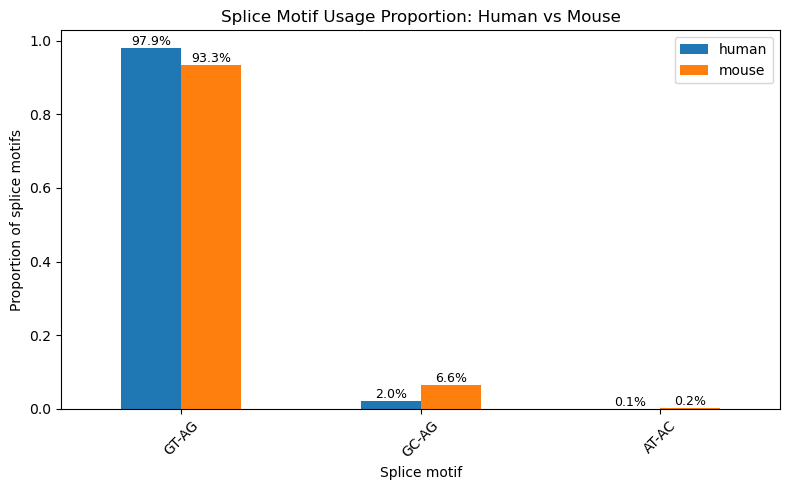

In [5]:
from collections import Counter
import pandas as pd

# Count motif occurrences
human_motifs = Counter(human_atse["splice_motif"])
mouse_motifs = Counter(mouse_atse["splice_motif"])

# Combine into a dataframe
motif_df = pd.DataFrame([human_motifs, mouse_motifs], index=["human", "mouse"]).fillna(0)

# Add proportions
motif_df_prop = motif_df.div(motif_df.sum(axis=1), axis=0)

# Plot the bar chart again with percentages as text
ax = motif_df_prop.T.plot(kind="bar", figsize=(8, 5))
ax.set_ylabel("Proportion of splice motifs")
ax.set_xlabel("Splice motif")
ax.set_title("Splice Motif Usage Proportion: Human vs Mouse")
plt.xticks(rotation=45)

# Annotate each bar with the percentage value
for container in ax.containers:
    for bar in container:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f"{height*100:.1f}%", 
                        (bar.get_x() + bar.get_width() / 2, height),
                        ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Donor/Acceptor Read Distributions')

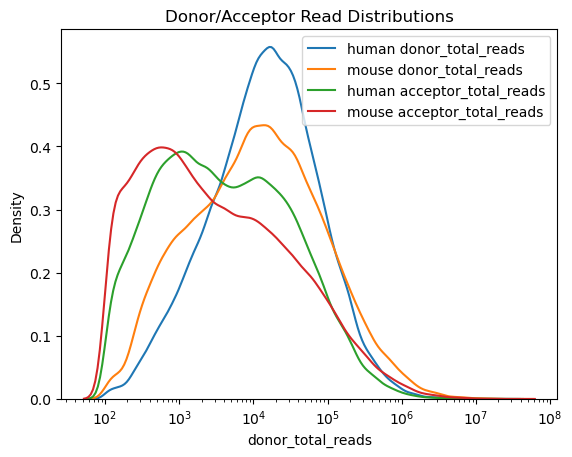

In [6]:
for col in ["donor_total_reads", "acceptor_total_reads"]:
    sns.kdeplot(human_atse[col], label=f"human {col}", log_scale=True)
    sns.kdeplot(mouse_atse[col], label=f"mouse {col}", log_scale=True)
plt.legend()
plt.title("Donor/Acceptor Read Distributions")


In [7]:
o_genes = orthos[["Gene stable ID", "Mouse gene stable ID", "Last common ancestor with Mouse", "Mouse homology type", "Mouse gene name", "Gene name"]].drop_duplicates()
o_genes = o_genes[o_genes["Mouse homology type"].isin(["ortholog_one2one", "ortholog_one2many"])]
o_genes

,Gene stable ID,Mouse gene stable ID,Last common ancestor with Mouse,Mouse homology type,Mouse gene name,Gene name
0,ENSG00000198888,ENSMUSG00000064341,Euarchontoglires,ortholog_one2one,mt-Nd1,MT-ND1
1,ENSG00000198763,ENSMUSG00000064345,Euarchontoglires,ortholog_one2one,mt-Nd2,MT-ND2
2,ENSG00000198804,ENSMUSG00000064351,Euarchontoglires,ortholog_one2one,mt-Co1,MT-CO1
3,ENSG00000198712,ENSMUSG00000064354,Mammalia,ortholog_one2one,mt-Co2,MT-CO2
4,ENSG00000228253,ENSMUSG00000064356,Euarchontoglires,ortholog_one2one,mt-Atp8,MT-ATP8
...,...,...,...,...,...,...
178975,ENSG00000278757,ENSMUSG00000119731,Theria,ortholog_one2many,Gm23096,U6
178976,ENSG00000243749,ENSMUSG00000070737,Euarchontoglires,ortholog_one2one,Tmem35b,TMEM35B
178977,ENSG00000163867,ENSMUSG00000042408,Euarchontoglires,ortholog_one2one,Zmym6,ZMYM6
178986,ENSG00000197056,ENSMUSG00000043872,Euarchontoglires,ortholog_one2one,Zmym1,ZMYM1


In [8]:
mouse_atse["gene_id"] = mouse_atse["gene_id"].str.split(".").str[0]
human_atse["gene_id"] = human_atse["gene_id"].str.split(".").str[0]

mouse_atse["Mouse gene stable ID"] = mouse_atse["gene_id"]
human_atse["Gene stable ID"] = human_atse["gene_id"]
mouse_atse["Mouse gene name"] = mouse_atse["gene_name"]
human_atse["Gene name"] = human_atse["gene_name"]

In [9]:
mouse_atse = mouse_atse.merge(o_genes, on=["Mouse gene stable ID", "Mouse gene name"])
human_atse = human_atse.merge(o_genes, on=["Gene stable ID", "Gene name"])

In [10]:
human_atse = human_atse[human_atse["Mouse gene stable ID"].isin(mouse_atse["Mouse gene stable ID"])]
mouse_atse = mouse_atse[mouse_atse["Gene stable ID"].isin(human_atse["Gene stable ID"])]

In [11]:
gene=human_atse["Mouse gene stable ID"].sample(n=1).values[0]
human_atse[human_atse["Mouse gene stable ID"] == gene]["event_id"], mouse_atse[mouse_atse["Mouse gene stable ID"] == gene]["event_id"]

(105918    ATSE_44115
 105919    ATSE_44115
 105920    ATSE_44115
 105921    ATSE_44115
 105922    ATSE_44115
 105923    ATSE_44116
 105924    ATSE_44116
 105925    ATSE_44116
 105926    ATSE_44116
 105927    ATSE_44116
 105928    ATSE_44116
 105929    ATSE_44116
 105930    ATSE_44116
 Name: event_id, dtype: object,
 27655    ATSE_17766
 27656    ATSE_17766
 27657    ATSE_17766
 27658    ATSE_17766
 27659    ATSE_17767
 27660    ATSE_17767
 Name: event_id, dtype: object)

In [12]:
human_event="ATSE_18923"
mouse_event="ATSE_18193"

{'ENSMUST00000088940.5': {'transcript_id': 'ENSMUST00000088940.5', 'transcript_name': 'Tmem181a-201', 'transcript_type': 'protein_coding', 'chromosome': 'chr17', 'exons': [(6270470, 6270590), (6280598, 6280701), (6286926, 6286981), (6288986, 6289073), (6290557, 6290678), (6294924, 6295034), (6295722, 6295802), (6297228, 6297327), (6297852, 6297982), (6298149, 6298240), (6299363, 6299420), (6300892, 6300994), (6301402, 6301453), (6303221, 6303303), (6304246, 6304335), (6304577, 6304643), (6305369, 6308314)], 'cds': [(6270583, 6270590), (6280598, 6280701), (6286926, 6286981), (6288986, 6289073), (6290557, 6290678), (6294924, 6295034), (6295722, 6295802), (6297228, 6297327), (6297852, 6297982), (6298149, 6298240), (6299363, 6299420), (6300892, 6300994), (6301402, 6301453), (6303221, 6303303), (6304246, 6304335), (6304577, 6304643), (6305369, 6305444)], 'strand': '+'}, 'ENSMUST00000228334.1': {'transcript_id': 'ENSMUST00000228334.1', 'transcript_name': 'Tmem181a-202', 'transcript_type': 'p

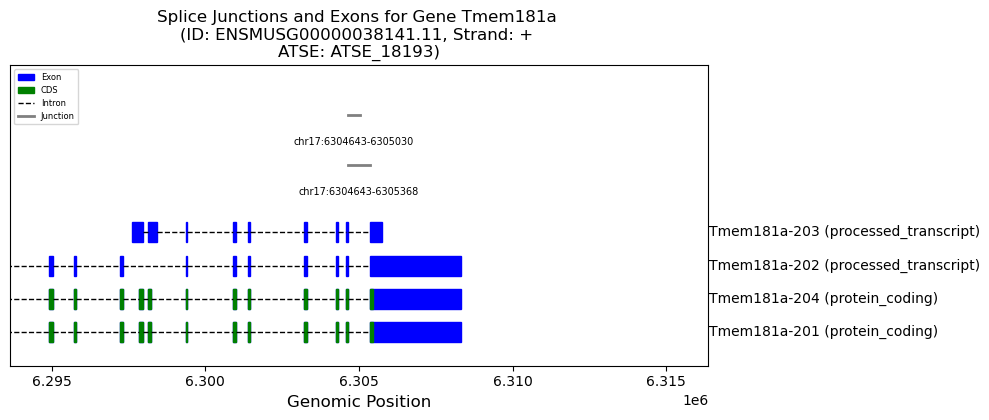

In [13]:
atse_event = mouse_event
juncs = mouse_atse[mouse_atse["event_id"] == atse_event].copy()

# Use .loc to set values
juncs.loc[:, "usage_ratio"] = juncs["total_score"] / juncs["total_score"].sum()
juncs.loc[:, "Cluster"] = juncs["event_id"]

# Now convert junction IDs
splice_junctions = convert_junction_ids(juncs)

# Fetch transcript exon coordinates and determine plot boundaries
unique_transcripts = extract_unique_transcripts(juncs)
transcript_data = fetch_transcripts_and_annotations(db_mouse, unique_transcripts)
print(transcript_data) 

# From trancsript data get transcript_id to transcript_name to transcript_type mapping
conversions = {}
for t in transcript_data.keys():
    transcript_id = transcript_data[t]["transcript_id"]
    transcript_name = transcript_data[t]["transcript_name"]
    transcript_type = transcript_data[t]["transcript_type"]
    conversions[transcript_id] = {
        "transcript_name": transcript_name,
        "transcript_type": transcript_type, 
        "transcript_id": transcript_id
    } 

# convert to dataframe 
conversions_df = pd.DataFrame.from_dict(conversions, orient='index')
print(conversions_df)

# Plot the junctions/transcripts involved in the ATSE 
region_start, region_end = determine_region_boundaries(splice_junctions)
plot_exons_and_junctions(db_mouse, atse_event, transcript_data, splice_junctions, region_start-10000, region_end+10000, 
                         base_width=10, trans_height=0.8, show_usage=False, show_junc_lines=False, filename="test.pdf")

{'ENST00000367090.4': {'transcript_id': 'ENST00000367090.4', 'transcript_name': 'TMEM181-201', 'transcript_type': 'protein_coding', 'chromosome': 'chr6', 'exons': [(158536436, 158536865), (158573420, 158573523), (158580940, 158580995), (158583954, 158584044), (158585304, 158585425), (158589672, 158589782), (158605267, 158605347), (158607244, 158607343), (158608333, 158608463), (158608659, 158608750), (158623550, 158623607), (158625104, 158625206), (158625703, 158625754), (158628408, 158628490), (158629730, 158629819), (158631323, 158631389), (158631810, 158635428)], 'cds': [(158536735, 158536865), (158573420, 158573523), (158580940, 158580995), (158583954, 158584044), (158585304, 158585425), (158589672, 158589782), (158605267, 158605347), (158607244, 158607343), (158608333, 158608463), (158608659, 158608750), (158623550, 158623607), (158625104, 158625206), (158625703, 158625754), (158628408, 158628490), (158629730, 158629819), (158631323, 158631389), (158631810, 158631885)], 'strand': 

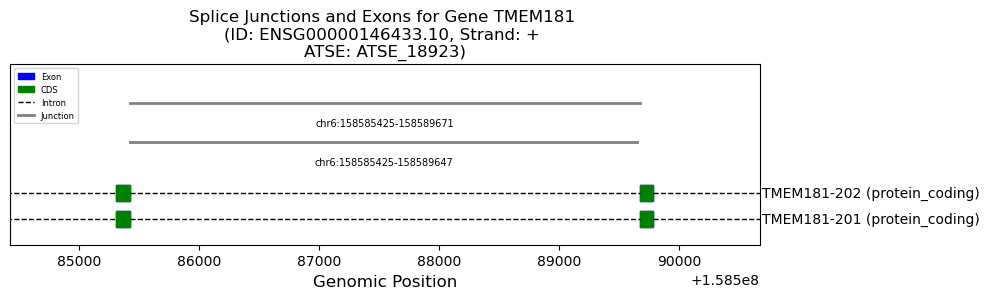

In [14]:
atse_event = human_event
juncs = human_atse[human_atse["event_id"] == atse_event].copy()

# Use .loc to set values
juncs.loc[:, "usage_ratio"] = juncs["total_score"] / juncs["total_score"].sum()
juncs.loc[:, "Cluster"] = juncs["event_id"]

# Now convert junction IDs
splice_junctions = convert_junction_ids(juncs)

# Fetch transcript exon coordinates and determine plot boundaries
unique_transcripts = extract_unique_transcripts(juncs)
transcript_data = fetch_transcripts_and_annotations(db_human, unique_transcripts)
print(transcript_data) 

# From trancsript data get transcript_id to transcript_name to transcript_type mapping
conversions = {}
for t in transcript_data.keys():
    transcript_id = transcript_data[t]["transcript_id"]
    transcript_name = transcript_data[t]["transcript_name"]
    transcript_type = transcript_data[t]["transcript_type"]
    conversions[transcript_id] = {
        "transcript_name": transcript_name,
        "transcript_type": transcript_type, 
        "transcript_id": transcript_id
    } 

# convert to dataframe 
conversions_df = pd.DataFrame.from_dict(conversions, orient='index')
print(conversions_df)

# Plot the junctions/transcripts involved in the ATSE 
region_start, region_end = determine_region_boundaries(splice_junctions)
plot_exons_and_junctions(db_human, atse_event, transcript_data, splice_junctions, region_start, region_end, 
                         base_width=10, trans_height=1, show_usage=False, show_junc_lines=False, filename="test.pdf")

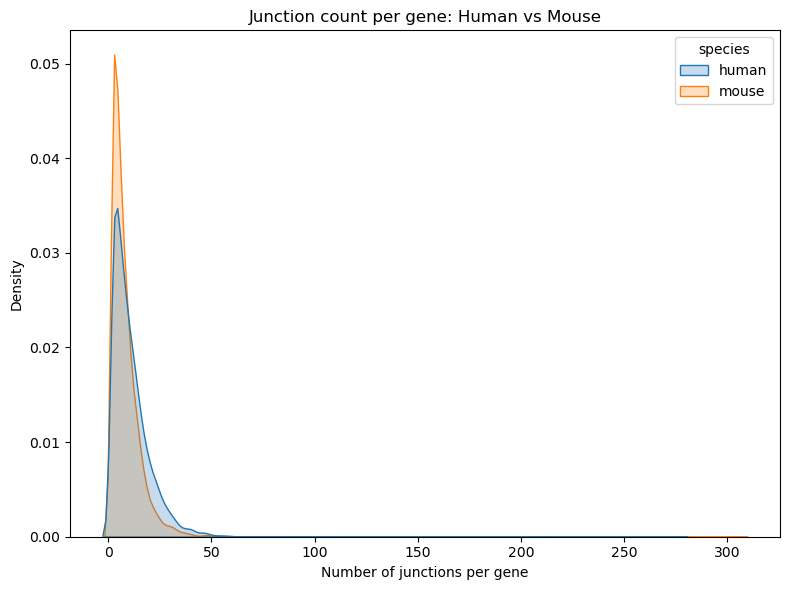

In [15]:
# Count junctions per gene
human_counts = human_atse["gene_id"].value_counts()
mouse_counts = mouse_atse["gene_id"].value_counts()

# Convert value_counts Series into DataFrame
human_df = human_counts.rename("junction_count").reset_index()
human_df["species"] = "human"

mouse_df = mouse_counts.rename("junction_count").reset_index()
mouse_df["species"] = "mouse"

# Combine
combined_df = pd.concat([human_df, mouse_df], ignore_index=True)

# Plot
plt.figure(figsize=(8, 6))
sns.kdeplot(data=combined_df, x="junction_count", hue="species", fill=True)
plt.xlabel("Number of junctions per gene")
plt.ylabel("Density")
plt.title("Junction count per gene: Human vs Mouse")
plt.tight_layout()
plt.show()

In [16]:
combined_df[combined_df["junction_count"] > 50]

,gene_id,junction_count,species
0,ENSG00000196378,276,human
1,ENSG00000243156,209,human
2,ENSG00000185842,106,human
3,ENSG00000118997,105,human
4,ENSG00000185885,96,human
5,ENSG00000149742,95,human
6,ENSG00000186526,84,human
7,ENSG00000179397,84,human
8,ENSG00000100197,77,human
9,ENSG00000155657,75,human


In [17]:
mouse_atse[mouse_atse["gene_id"] == "ENSMUSG00000002546"]

,event_id,gene_id,gene_name,gene_types,num_junctions,event_type,transcript_types,annotation_status,perfect_match_5_prime,perfect_match_3_prime,...,donor_seq,acceptor_seq,position_off_5_prime,position_off_3_prime,Mouse gene stable ID,Mouse gene name,Gene stable ID,Last common ancestor with Mouse,Mouse homology type,Gene name
44957,ATSE_28293,ENSMUSG00000002546,Golga2,protein_coding,6,complex,"protein_coding,retained_intron",both,"ENSMUST00000139494.7,ENSMUST00000113377.7,ENSM...","ENSMUST00000139494.7,ENSMUST00000113377.7,ENSM...",...,GT,AG,0.0,1.0,ENSMUSG00000002546,Golga2,ENSG00000167110,Amniota,ortholog_one2many,GOLGA2
44959,ATSE_28293,ENSMUSG00000002546,Golga2,protein_coding,6,complex,"protein_coding,retained_intron",both,"ENSMUST00000139494.7,ENSMUST00000113377.7,ENSM...","ENSMUST00000139494.7,ENSMUST00000113377.7,ENSM...",...,GT,AG,0.0,1.0,ENSMUSG00000002546,Golga2,ENSG00000206127,Amniota,ortholog_one2many,GOLGA8O
44960,ATSE_28293,ENSMUSG00000002546,Golga2,protein_coding,6,complex,"protein_coding,retained_intron",both,"ENSMUST00000139494.7,ENSMUST00000113377.7,ENSM...","ENSMUST00000139494.7,ENSMUST00000113377.7,ENSM...",...,GT,AG,0.0,1.0,ENSMUSG00000002546,Golga2,ENSG00000215252,Amniota,ortholog_one2many,GOLGA8B
44961,ATSE_28293,ENSMUSG00000002546,Golga2,protein_coding,6,complex,"protein_coding,retained_intron",both,"ENSMUST00000139494.7,ENSMUST00000113377.7,ENSM...","ENSMUST00000139494.7,ENSMUST00000113377.7,ENSM...",...,GT,AG,0.0,1.0,ENSMUSG00000002546,Golga2,ENSG00000261794,Amniota,ortholog_one2many,GOLGA8H
44962,ATSE_28293,ENSMUSG00000002546,Golga2,protein_coding,6,complex,"protein_coding,retained_intron",both,"ENSMUST00000139494.7,ENSMUST00000113377.7,ENSM...","ENSMUST00000139494.7,ENSMUST00000113377.7,ENSM...",...,GT,AG,0.0,1.0,ENSMUSG00000002546,Golga2,ENSG00000153684,Amniota,ortholog_one2many,GOLGA8F
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45275,ATSE_28297,ENSMUSG00000002546,Golga2,protein_coding,2,alternative_5_prime,"protein_coding,retained_intron",unannotated,NaN,NaN,...,GC,AG,9.0,NaN,ENSMUSG00000002546,Golga2,ENSG00000249931,Amniota,ortholog_one2many,GOLGA8K
45276,ATSE_28297,ENSMUSG00000002546,Golga2,protein_coding,2,alternative_5_prime,"protein_coding,retained_intron",unannotated,NaN,NaN,...,GC,AG,9.0,NaN,ENSMUSG00000002546,Golga2,ENSG00000186399,Amniota,ortholog_one2many,GOLGA8R
45277,ATSE_28297,ENSMUSG00000002546,Golga2,protein_coding,2,alternative_5_prime,"protein_coding,retained_intron",unannotated,NaN,NaN,...,GC,AG,9.0,NaN,ENSMUSG00000002546,Golga2,ENSG00000167195,Amniota,ortholog_one2many,GOLGA6C
45278,ATSE_28297,ENSMUSG00000002546,Golga2,protein_coding,2,alternative_5_prime,"protein_coding,retained_intron",unannotated,NaN,NaN,...,GC,AG,9.0,NaN,ENSMUSG00000002546,Golga2,ENSG00000232653,Amniota,ortholog_one2many,GOLGA8N


In [18]:
human_atse

,event_id,gene_id,gene_name,gene_types,num_junctions,event_type,transcript_types,annotation_status,perfect_match_5_prime,perfect_match_3_prime,...,donor_seq,acceptor_seq,position_off_5_prime,position_off_3_prime,Gene stable ID,Gene name,Mouse gene stable ID,Last common ancestor with Mouse,Mouse homology type,Mouse gene name
0,ATSE_18,ENSG00000221978,CCNL2,protein_coding,2,alternative_5_prime,"nonsense_mediated_decay,protein_coding,retaine...",both,ENST00000425598.2,"ENST00000400809.8,ENST00000496007.5,ENST000004...",...,GT,AG,1.0,0.0,ENSG00000221978,CCNL2,ENSMUSG00000029068,Euarchontoglires,ortholog_one2one,Ccnl2
1,ATSE_18,ENSG00000221978,CCNL2,protein_coding,2,alternative_5_prime,"nonsense_mediated_decay,protein_coding,retaine...",both,"ENST00000400809.8,ENST00000496007.5,ENST000004...","ENST00000400809.8,ENST00000496007.5,ENST000004...",...,GT,AG,1.0,0.0,ENSG00000221978,CCNL2,ENSMUSG00000029068,Euarchontoglires,ortholog_one2one,Ccnl2
2,ATSE_19,ENSG00000221978,CCNL2,protein_coding,8,complex,"protein_coding_CDS_not_defined,retained_intron",five_prime,"ENST00000496007.5,ENST00000482365.5",NaN,...,GT,AG,1.0,-24.0,ENSG00000221978,CCNL2,ENSMUSG00000029068,Euarchontoglires,ortholog_one2one,Ccnl2
3,ATSE_19,ENSG00000221978,CCNL2,protein_coding,8,complex,"protein_coding_CDS_not_defined,retained_intron",both,"ENST00000480479.5,ENST00000496007.5,ENST000005...","ENST00000480479.5,ENST00000505849.5",...,GT,AG,1.0,0.0,ENSG00000221978,CCNL2,ENSMUSG00000029068,Euarchontoglires,ortholog_one2one,Ccnl2
4,ATSE_19,ENSG00000221978,CCNL2,protein_coding,8,complex,"protein_coding_CDS_not_defined,nonsense_mediat...",both,"ENST00000480479.5,ENST00000400809.8,ENST000004...","ENST00000496007.5,ENST00000482365.5",...,GT,AG,1.0,0.0,ENSG00000221978,CCNL2,ENSMUSG00000029068,Euarchontoglires,ortholog_one2one,Ccnl2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119988,ATSE_52079,ENSG00000161970,RPL26,protein_coding,2,alternative_5_prime,"protein_coding_CDS_not_defined,nonsense_mediat...",three_prime,NaN,"ENST00000648839.1,ENST00000584906.6,ENST000005...",...,GT,AG,NaN,0.0,ENSG00000161970,RPL26,ENSMUSG00000060938,Amniota,ortholog_one2one,Rpl26
119989,ATSE_52087,ENSG00000116703,PDC,protein_coding,2,alternative_5_prime,protein_coding,both,ENST00000391997.3,"ENST00000391997.3,ENST00000497198.1",...,GC,AG,1.0,0.0,ENSG00000116703,PDC,ENSMUSG00000006007,Euarchontoglires,ortholog_one2one,Pdc
119990,ATSE_52087,ENSG00000116703,PDC,protein_coding,2,alternative_5_prime,protein_coding,both,ENST00000497198.1,"ENST00000391997.3,ENST00000497198.1",...,GT,AG,1.0,0.0,ENSG00000116703,PDC,ENSMUSG00000006007,Euarchontoglires,ortholog_one2one,Pdc
119995,ATSE_52105,ENSG00000120068,HOXB8,protein_coding,2,alternative_3_prime,protein_coding,both,"ENST00000239144.5,ENST00000576562.1",ENST00000576562.1,...,GT,AG,1.0,0.0,ENSG00000120068,HOXB8,ENSMUSG00000056648,Euarchontoglires,ortholog_one2one,Hoxb8
